# Barcelona pressing intensity analysis — La Liga 2015/16

In [9]:
!pip install mplsoccer statsbombpy -q

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from mplsoccer import Pitch
from statsbombpy import sb


In [10]:
matches = sb.matches(competition_id=11, season_id=26)
print(matches[['match_id', 'home_team', 'away_team', 'match_date']].to_string())

    match_id               home_team               away_team  match_date
0     267183               Barcelona             Real Madrid  2015-03-22
1     265835               Barcelona                 Sevilla  2014-11-22
2     266838                  Málaga               Barcelona  2014-09-24
3     265963               Barcelona                  Getafe  2015-04-28
4     266117               Barcelona                 Granada  2014-09-27
5     266916               Barcelona          Rayo Vallecano  2015-03-08
6     267197               Barcelona  RC Deportivo La Coruña  2015-05-23
7      70264                  Getafe               Barcelona  2014-12-13
8      70273               Barcelona           Athletic Club  2014-09-13
9     267301               Barcelona              Celta Vigo  2014-11-01
10    265896               Barcelona                   Eibar  2014-10-18
11    265866              Córdoba CF               Barcelona  2015-05-02
12    267400               Barcelona               

In [11]:
# Load all events from all matches
all_events = []

for match_id in matches['match_id']:
    try:
        events = sb.events(match_id=match_id)
        all_events.append(events)
    except:
        pass

all_events = pd.concat(all_events, ignore_index=True)
print(f"Total events loaded: {len(all_events)}")

Total events loaded: 142957


In [13]:
ppda_per_match = []

for match_id in matches['match_id']:
    match_events = all_events[all_events['match_id'] == match_id]
    match_info = matches[matches['match_id'] == match_id].iloc[0]

    opponent = match_info['away_team'] if match_info['home_team'] == 'Barcelona' else match_info['home_team']

    match_passes = match_events[match_events['type'] == 'Pass'].copy()
    match_passes['x'] = match_passes['location'].apply(lambda loc: loc[0])

    match_def = match_events[match_events['type'].isin(['Pressure', 'Interception', 'Tackle', 'Block'])]

    barca_def = len(match_def[match_def['team'] == 'Barcelona'])
    opp_passes_def_zone = len(match_passes[(match_passes['team'] != 'Barcelona') & (match_passes['x'] < 60)])

    if barca_def > 0:
        ppda = opp_passes_def_zone / barca_def
        ppda_per_match.append({
            'opponent': opponent,
            'ppda': round(ppda, 2)
        })

ppda_df = pd.DataFrame(ppda_per_match).sort_values('ppda')
print(ppda_df.to_string())

                  opponent  ppda
18         Atlético Madrid  0.69
22                 Granada  0.85
23         Atlético Madrid  0.88
35              Celta Vigo  0.91
26                Valencia  0.93
17           Real Sociedad  0.94
31                 Almería  0.94
27                Valencia  0.95
2                   Málaga  0.98
25  RC Deportivo La Coruña  1.05
9               Celta Vigo  1.06
0              Real Madrid  1.10
11              Córdoba CF  1.11
15          Rayo Vallecano  1.13
21                   Elche  1.14
19           Real Sociedad  1.19
37                 Sevilla  1.21
16                  Málaga  1.21
6   RC Deportivo La Coruña  1.22
24                Espanyol  1.28
20              Villarreal  1.30
13              Villarreal  1.31
1                  Sevilla  1.32
29                Espanyol  1.42
3                   Getafe  1.45
36              Levante UD  1.51
12                 Almería  1.58
14             Real Madrid  1.59
5           Rayo Vallecano  1.60
4         

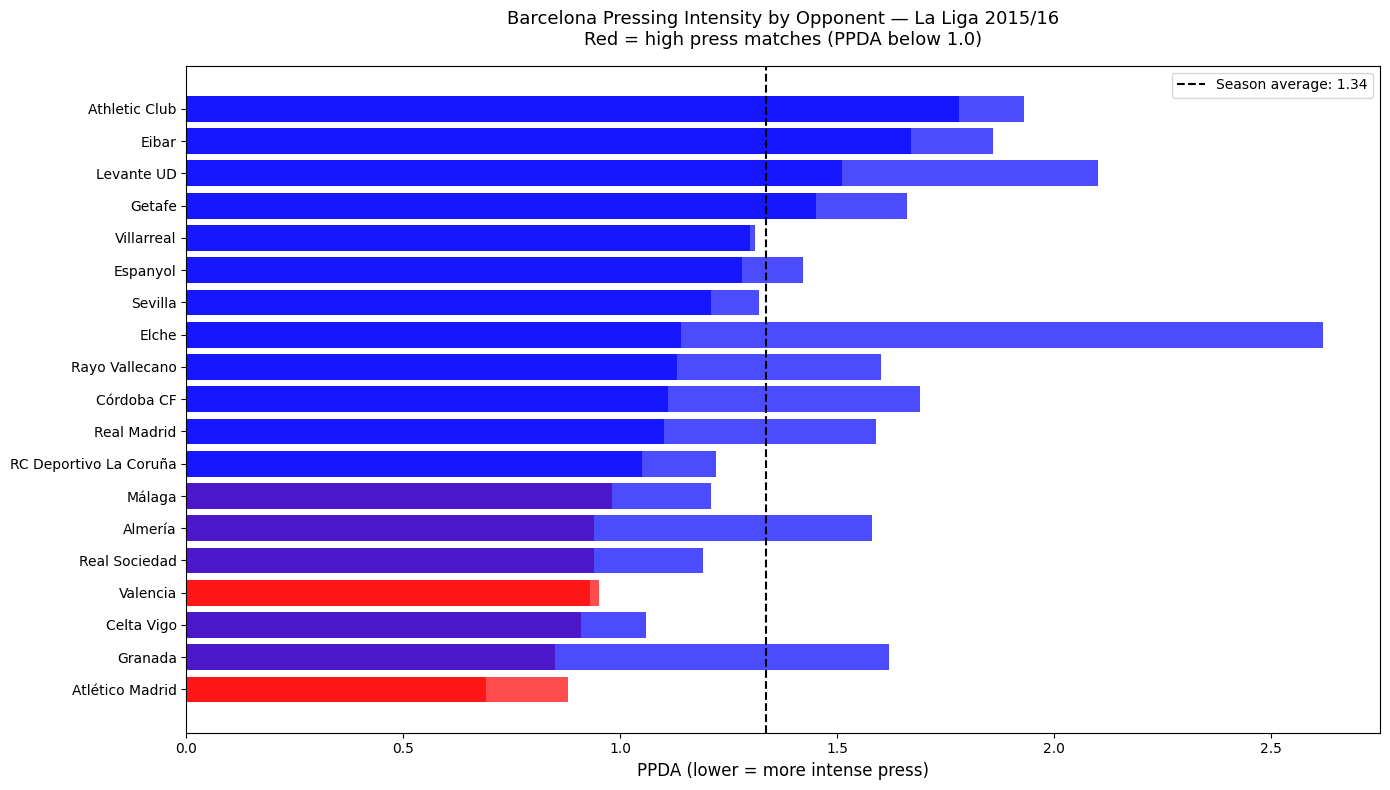

In [14]:
fig, ax = plt.subplots(figsize=(14, 8))

colors = ['red' if ppda <= 1.0 else 'blue' for ppda in ppda_df['ppda']]

bars = ax.barh(ppda_df['opponent'], ppda_df['ppda'], color=colors, alpha=0.7)

ax.axvline(ppda_df['ppda'].mean(), color='black', linestyle='--',
           linewidth=1.5, label=f"Season average: {ppda_df['ppda'].mean():.2f}")

ax.set_xlabel('PPDA (lower = more intense press)', fontsize=12)
ax.set_title("Barcelona Pressing Intensity by Opponent — La Liga 2015/16\nRed = high press matches (PPDA below 1.0)",
             fontsize=13, pad=15)
ax.legend()
plt.tight_layout()
plt.show()

The bar chart shows Barcelona's PPDA against every opponent in La Liga 2015/16. Against teams like Atlético Madrid and Valencia, Barcelona's PPDA dropped below 1.0 meaning they were pressing extremely intensely — because both teams are known for winning possession back quickly and not allowing Barcelona to play freely, which forced Barcelona to respond with a higher press. On the other hand against a team like Elche, Barcelona's PPDA was above 2.5 meaning they barely pressed at all — Elche sat deep and defended the whole match, giving Barcelona the ball and never threatening, so there was no need to press.

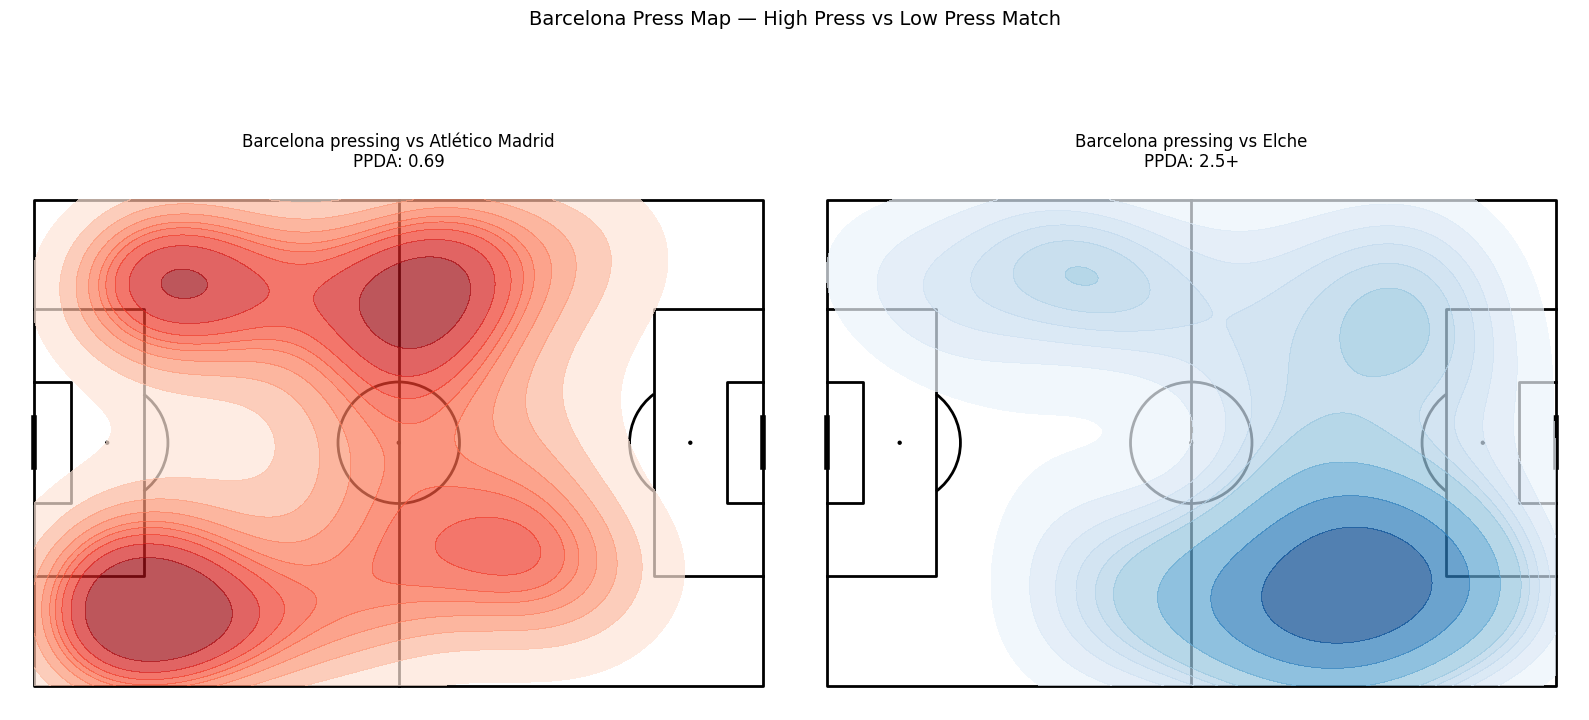

In [15]:
# Get pressing locations for Barcelona vs Atletico and vs Elche
atletico_match = matches[matches['away_team'] == 'Atlético Madrid'].iloc[0]
elche_match = matches[matches['away_team'] == 'Elche'].iloc[0]

# Try home matches if away not found
if len(matches[matches['away_team'] == 'Atlético Madrid']) == 0:
    atletico_match = matches[matches['home_team'] == 'Atlético Madrid'].iloc[0]
if len(matches[matches['away_team'] == 'Elche']) == 0:
    elche_match = matches[matches['home_team'] == 'Elche'].iloc[0]

atletico_events = all_events[all_events['match_id'] == atletico_match['match_id']]
elche_events = all_events[all_events['match_id'] == elche_match['match_id']]

# Barcelona pressures in each match
atletico_press = atletico_events[
    (atletico_events['type'] == 'Pressure') &
    (atletico_events['team'] == 'Barcelona')
].copy()
elche_press = elche_events[
    (elche_events['type'] == 'Pressure') &
    (elche_events['team'] == 'Barcelona')
].copy()

atletico_press['x'] = atletico_press['location'].apply(lambda loc: loc[0])
atletico_press['y'] = atletico_press['location'].apply(lambda loc: loc[1])
elche_press['x'] = elche_press['location'].apply(lambda loc: loc[0])
elche_press['y'] = elche_press['location'].apply(lambda loc: loc[1])

pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black')
fig, axes = pitch.draw(ncols=2, figsize=(16, 8))

pitch.kdeplot(atletico_press['x'], atletico_press['y'], ax=axes[0],
              fill=True, cmap='Reds', levels=10, alpha=0.7)
axes[0].set_title(f'Barcelona pressing vs Atlético Madrid\nPPDA: 0.69', fontsize=12)

pitch.kdeplot(elche_press['x'], elche_press['y'], ax=axes[1],
              fill=True, cmap='Blues', levels=10, alpha=0.7)
axes[1].set_title(f'Barcelona pressing vs Elche\nPPDA: 2.5+', fontsize=12)

plt.suptitle("Barcelona Press Map — High Press vs Low Press Match", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

The comparison map shows two completely different pressing styles from Barcelona. Against Atlético Madrid, Barcelona pressed deep or from the middle third — because Atlético were known for their dangerous counter attacks with Griezmann, pressing high would have left Barcelona exposed in behind. It was a calculated decision to stay compact and press in safer areas. Against Elche, one of the smallest clubs in La Liga that season, Barcelona barely pressed at all for most of the match because Elche sat deep and gave them the ball — but when Barcelona did press it was high up in Elche's half, winning the ball back in dangerous areas and creating chances quickly. The data shows that Barcelona's pressing was not a fixed system but an intelligent adaptation to each opponent's threat level.